## High resolution mapping of the breast cancer tumor microenvironment using integrated single cell, spatial and in situ analysis of FFPE tissue
Amanda Janesick, Robert Shelansky, Andrew Gottscho, Florian Wagner, Morgane Rouault, Ghezal Beliakoff, Michelli Faria de Oliveira, Andrew Kohlway, Jawad Abousoud, Carolyn Morrison, Tingsheng Yu Drennon, Syrus Mohabbat, Stephen Williams, 10x Development Teams, Sarah Taylor

October 20, 2023

Link to the paper: https://www.biorxiv.org/content/10.1101/2022.10.06.510405v1

Link to the data: https://www.10xgenomics.com/products/xenium-in-situ/preview-dataset-human-breast

Available for download from GitHub: https://github.com/10XGenomics/janesick_nature_comms_2023_companion
![image.png](./figures/F1.large.jpg)



### Saving the cell_groups.csv file
The ```Cell_Barcode_Type_Matrices.xlsx``` contains all the annotation for the paper. For this analysis we will only make use of the supervised labeling from Xenium Sample 1, Replicate 1. Use ```SaveAs``` to save the ```Xenium R1 Fig1-5 (supervised)``` tab as a CSV file. We will refer to it in the code as the ```cell_groups.csv```. Move the ```cell_groups.csv``` into the ```xenium-publication``` directory we just created. 

In [ ]:
# ## 2024.01.09 LLY add
# cd /mnt/lingyu/nfs_share2/Python/
# cp -r iSTAR/GSE243280/GSM7780153_Xenium_R1_Fig1-5_supervised.csv.gz Xenium/xenium-publication/GSM7780153_Xenium_R1_Fig1-5_supervised.csv.gz
# cd Xenium/xenium-publication/
# gunzip GSM7780153_Xenium_R1_Fig1-5_supervised.csv.gz
# cp -r GSM7780153_Xenium_R1_Fig1-5_supervised.csv cell_groups.csv


## 2024.01.09 Try to run this demo and gen the expression of one gene using Xunimum data
## using the Python 3(ipykernel) 在安装过程中默认的
## 2024.07.31 Update the ROI, using Polygon
## 2024.08.02 Xenium ground truth, using the sing cell data, not binned_spot 
## 2024.08.06 Xenium ground truth, using the sing cell data and binned_spot as ground truth
## 2024.08.07 add the TransImp results, using pseudo-visium
## 2026.06.20 copy form woody and see the Hist2Pheno results
##            FIneST env

## Losd h5, add cell type info and save h5ad 

### Xenium adata: cell_feature_matrix
See: Xenium Cell feature matrix

https://localhost:8888/notebooks/SpatialScope/Nuclei_Segmentation_ROIcompare.ipynb

See: Cell type spatial map

https://localhost:8888/notebooks/Xenium/janesick_nature_comms_2023_companion-main/companion_notebook_compare_ROI_istar.ipynb


In [8]:
import os
# path = '/Users/lilingyu/E/PhD/Python/'
# path = '/storage3/yhhuang/users/lingyu/'
# path = '/data/users/lingyu/'
# path = '/home/lly/Python/'
# path = '/mnt/lingyu/nfs_share2/Python/'
path = '/home/lingyu/ssd2/Python/'
path_brca = f'{path}Collaborate/esccAI/data/Xemiun/BRCA/xenium-publication/'

In [9]:
import scanpy as sc
import pandas as pd
import numpy as np

xenium_mat = sc.read_10x_h5(f'{path_brca}xenium/outs/cell_feature_matrix.h5')
print(xenium_mat)
print(xenium_mat.obs_names)
print(xenium_mat.var_names)

xenium_celltype = pd.read_csv(f'{path_brca}cell_groups.csv')
xenium_celltype['Cluster'] = xenium_celltype['Cluster'].str.replace('_', ' ')
print('The shape of xenium_celltype:', xenium_celltype.shape)
display(xenium_celltype.head())

## Read in the Xenium cell positions and cell metadata.
xenium_cell_info = pd.read_csv(f'{path_brca}xenium/outs/cells.csv.gz')
display(xenium_cell_info.head())

xenium_mat.obsm['spatial'] = np.array(xenium_cell_info[['x_centroid','y_centroid']])
print(xenium_mat)

# xenium_mat_copy._init_as_actual()
xenium_mat.obs['cell_type'] = xenium_celltype['Cluster'].values
# xenium_mat_copy.var  = xenium_mat.var
print(xenium_mat)
print(xenium_mat.obs['cell_type'])

## save adata
# xenium_mat.write(f'{path_brca}xenium_cell_feature_matrix.h5ad')

AnnData object with n_obs × n_vars = 167780 × 313
    var: 'gene_ids', 'feature_types', 'genome'
Index(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10',
       ...
       '167771', '167772', '167773', '167774', '167775', '167776', '167777',
       '167778', '167779', '167780'],
      dtype='object', length=167780)
Index(['ABCC11', 'ACTA2', 'ACTG2', 'ADAM9', 'ADGRE5', 'ADH1B', 'ADIPOQ',
       'AGR3', 'AHSP', 'AIF1',
       ...
       'TUBB2B', 'TYROBP', 'UCP1', 'USP53', 'VOPP1', 'VWF', 'WARS', 'ZEB1',
       'ZEB2', 'ZNF562'],
      dtype='object', length=313)
The shape of xenium_celltype: (167780, 2)


,Barcode,Cluster
0,1,DCIS 2
1,2,DCIS 2
2,3,Unlabeled
3,4,Invasive Tumor
4,5,DCIS 2


,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,total_counts,cell_area,nucleus_area
0,1,847.259912,326.191365,28,1,0,29,58.387031,26.642187
1,2,826.341995,328.031830,94,0,0,94,197.016719,42.130781
2,3,848.766919,331.743187,9,0,0,9,16.256250,12.688906
3,4,824.228409,334.252643,11,0,0,11,42.311406,10.069844
4,5,841.357538,332.242505,48,0,0,48,107.652500,37.479687


AnnData object with n_obs × n_vars = 167780 × 313
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 167780 × 313
    obs: 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'
1                 DCIS 2
2                 DCIS 2
3              Unlabeled
4         Invasive Tumor
5                 DCIS 2
               ...      
167776            DCIS 1
167777            DCIS 2
167778            DCIS 1
167779            DCIS 2
167780            DCIS 1
Name: cell_type, Length: 167780, dtype: object


### `obsm['spatial']` vs HE image pixel coordinates

`xenium_mat.obsm['spatial']` is filled from `cells.csv.gz` columns **`x_centroid` / `y_centroid`**. These are **Xenium morphology coordinates in microns (µm)**, not HE TIFF pixel indices.

To overlay cells on `Xenium_FFPE_Human_Breast_Cancer_Rep1_he_image.tif`, convert with the same Xenium helper used in the lung workflow (`xenium_coords.add_he_pixel_columns`, morphology pixel size **0.2125 µm/px**):

- `X_pix_HE = x_centroid / 0.2125`
- `Y_pix_HE = y_centroid / 0.2125`

Note: coordinates come from `xenium_cell_info` (`cells.csv.gz`), not from `cell_groups.csv` (which only has `Barcode` + `Cluster`).

In [ ]:
import sys
import importlib
from pathlib import Path
import tifffile
import matplotlib.pyplot as plt

_xenium_lung_dir = Path(path).resolve() / "Collaborate/esccAI/code/Xenium_lung"
if str(_xenium_lung_dir) not in sys.path:
    sys.path.insert(0, str(_xenium_lung_dir))

import xenium_coords
importlib.reload(xenium_coords)
from xenium_coords import add_he_pixel_columns, XENIUM_UM_PER_PX

# 1) micron coords -> HE morphology pixel coords
xenium_cell_info_HE = add_he_pixel_columns(xenium_cell_info)
print("xenium_cell_info_HE shape:", xenium_cell_info_HE.shape)
display(xenium_cell_info_HE.head())

# 2) sanity check against the publication HE image
he_tif_path = Path(f"{path_brca}Xenium_FFPE_Human_Breast_Cancer_Rep1_he_image.tif")
he_img = tifffile.imread(he_tif_path)
he_h, he_w = he_img.shape[:2]
print(f"HE image shape (H, W): ({he_h}, {he_w})")
print(f"Conversion: um_per_px = {XENIUM_UM_PER_PX}")

in_bounds = (
    (xenium_cell_info_HE["X_pix_HE"] >= 0)
    & (xenium_cell_info_HE["X_pix_HE"] < he_w)
    & (xenium_cell_info_HE["Y_pix_HE"] >= 0)
    & (xenium_cell_info_HE["Y_pix_HE"] < he_h)
)
print(
    f"Cells within HE bounds: {in_bounds.sum():,}/{len(xenium_cell_info_HE):,} "
    f"({100 * in_bounds.mean():.1f}%)"
)
print(
    "X_pix_HE range:",
    float(xenium_cell_info_HE["X_pix_HE"].min()),
    float(xenium_cell_info_HE["X_pix_HE"].max()),
)
print(
    "Y_pix_HE range:",
    float(xenium_cell_info_HE["Y_pix_HE"].min()),
    float(xenium_cell_info_HE["Y_pix_HE"].max()),
)

# Visual check: in-bounds cells should fall on tissue in the HE image
plot_df = xenium_cell_info_HE.loc[in_bounds].sample(
    n=min(8000, in_bounds.sum()), random_state=0
)
downsample = 20
fig, ax = plt.subplots(figsize=(8, 8), dpi=120)
ax.imshow(he_img[::downsample, ::downsample])
ax.scatter(
    plot_df["X_pix_HE"] / downsample,
    plot_df["Y_pix_HE"] / downsample,
    s=0.2,
    c="red",
    alpha=0.35,
    linewidths=0,
)
ax.set_title("HE image + X_pix_HE / Y_pix_HE overlay (sampled in-bounds cells)")
ax.set_xlabel("X_pix_HE")
ax.set_ylabel("Y_pix_HE")
plt.show()

# 3) merge cell metadata + annotation, then save
xenium_cell_info_HE_by_annotation = xenium_cell_info_HE.merge(
    xenium_celltype,
    left_on="cell_id",
    right_on="Barcode",
    how="inner",
    validate="one_to_one",
)
print("xenium_cell_info_HE_by_annotation shape:", xenium_cell_info_HE_by_annotation.shape)
display(xenium_cell_info_HE_by_annotation.head())

out_csv = Path(f"{path_brca}xenium_cell_info_HE_by_annotation.csv")
xenium_cell_info_HE_by_annotation.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")

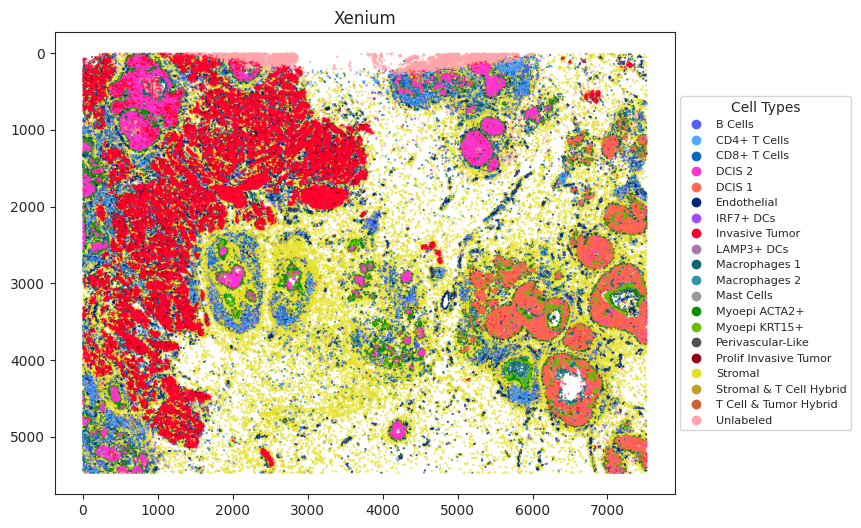

In [10]:
# import scanpy as sc
# xenium_mat = sc.read_h5ad(f'{path_brca}xenium_cell_feature_matrix.h5ad')
# print(xenium_mat)
# print(xenium_mat.obsm["spatial"])


## Cell type color map
ctype_hex_map_xenium = {'B Cells': '#565DFD',
 'CD4+ T Cells': '#4fa9ff',
 'CD8+ T Cells': '#1068be',
 # 'DCIS 1': '#fb34cd',
 # 'DCIS 2': '#FE664D',
 'DCIS 2': '#fb34cd',
 'DCIS 1': '#FE664D',
 'Endothelial': '#01257b',
 'IRF7+ DCs': '#9f50f9',
 'Invasive Tumor': '#ff002a',
 'LAMP3+ DCs': '#AB76AE',
 'Macrophages 1': '#10686f',
 'Macrophages 2': '#3694a8',
 'Mast Cells': '#999999',
 'Myoepi ACTA2+': '#009203',
 'Myoepi KRT15+': '#66c102',
 'Perivascular-Like': '#515151',
 'Prolif Invasive Tumor': '#8e0119',
 'Stromal': '#e5e022',
 'Stromal & T Cell Hybrid': '#C1A029',
 'T Cell & Tumor Hybrid': '#CB6035',
 'Unlabeled': '#ffa5aa'}

## plot 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("ticks")
fig, ax = plt.subplots(1, 1, figsize=(8,6), dpi=100)
colors = xenium_mat.obs['cell_type'].map(ctype_hex_map_xenium)
plt.scatter(xenium_mat.obsm['spatial'][:, 0], xenium_mat.obsm['spatial'][:, 1], s=0.2, c=colors)
legend_elements = [plt.Line2D([0], [0], linestyle='', marker='o', color=color, label=cell_type, markersize=6) 
                   for cell_type, color in ctype_hex_map_xenium.items()]
ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), title='Cell Types', fontsize=8)
ax.invert_yaxis()
plt.title('Xenium')
plt.show()

# os.chdir(str(path)+'SpatialData/Data/resultsROIs/')
# fig.savefig('Xenium_anno.pdf', format='pdf')

## HE image